In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '/home/jbreda/PROseq/scripts/Phase_to_LabColor')
from phase_to_labcolor import phase_to_labcolor as p2lc

In [2]:
genome = 'GRCm38'

# get gene gtf
infile_gtf = f"../resources/genome/{genome}/gene_annotation.gtf"
gene_gtf = pd.read_csv(infile_gtf, sep='\t', comment='#', header=None)
gene_gtf.columns = ['chrom','source','feature','start','end','score','strand','frame','attributes']
# parse the gtf's 9 th column (attributes sep by ;)
attributes = ['gene_id','gene_type','gene_name','transcript_id','transcript_type','transcript_name']
for att in attributes:
    gene_gtf[att] = gene_gtf['attributes'].str.extract(rf'{att} "(.*?)";')



# get extended kalman filter data
bin_size = 1000
infile_kalman = f"../results/{genome}/kalman/extended_kalman_on_chromosomes_bin{bin_size}bp.csv"
extended = pd.read_csv(infile_kalman, sep='\t')

# get bin phase amplitude
infile_bin_fw = f"../results/{genome}/phase_amp/bin_phase_amp_forward_10000bp.csv"
infile_bin_rv = f"../results/{genome}/phase_amp/bin_phase_amp_reverse_10000bp.csv"
bin_phase_amp = {}
bin_phase_amp['+'] = pd.read_csv(infile_bin_fw, sep='\t')
bin_phase_amp['-'] = pd.read_csv(infile_bin_rv, sep='\t')

# read gene phase amplitude
#infile_gene = f"../results/{genome}/phase_amp/gene_phase_amp.csv"
#gene_phase_amp = {}
#gene_phase_amp['proseq'] = pd.read_csv(infile_gene, sep='\t')



/tmp/ipykernel_780091/3496515499.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_780091/3496515499.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_780091/3496515499.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_780091/3496515499.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_780091/3496515499.py:136: Use

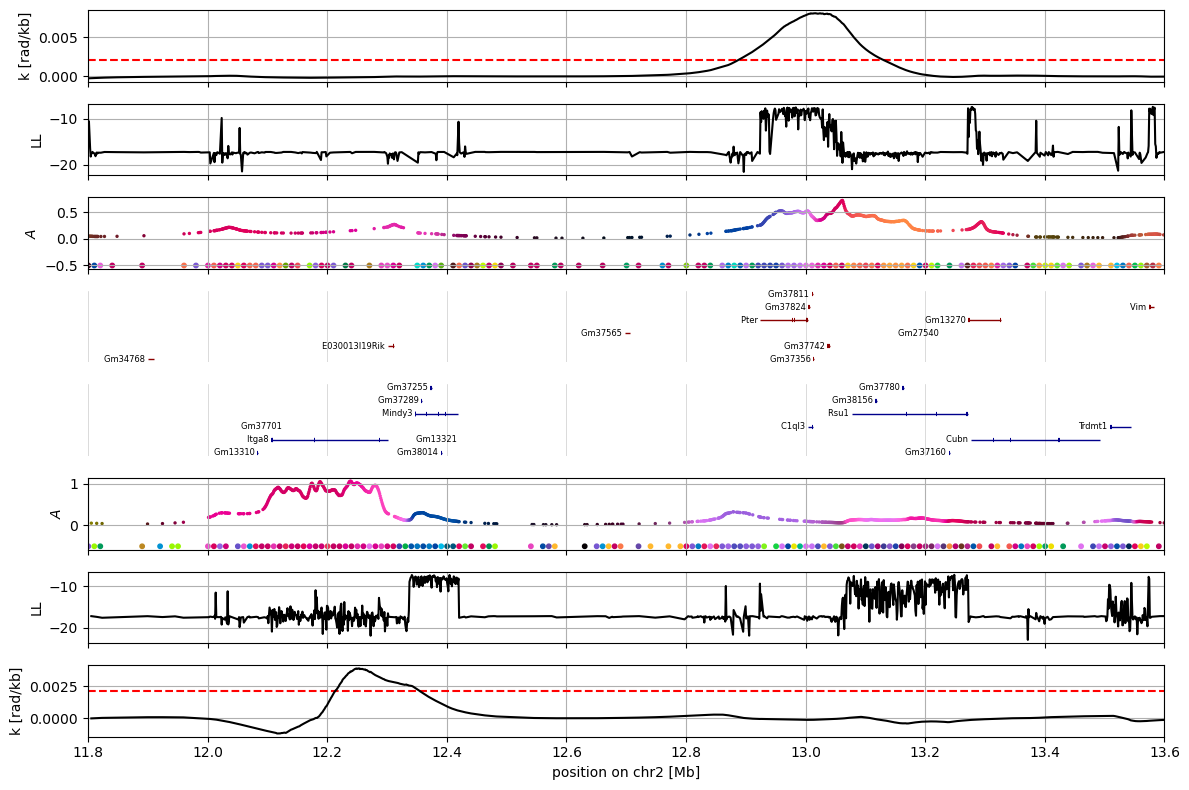

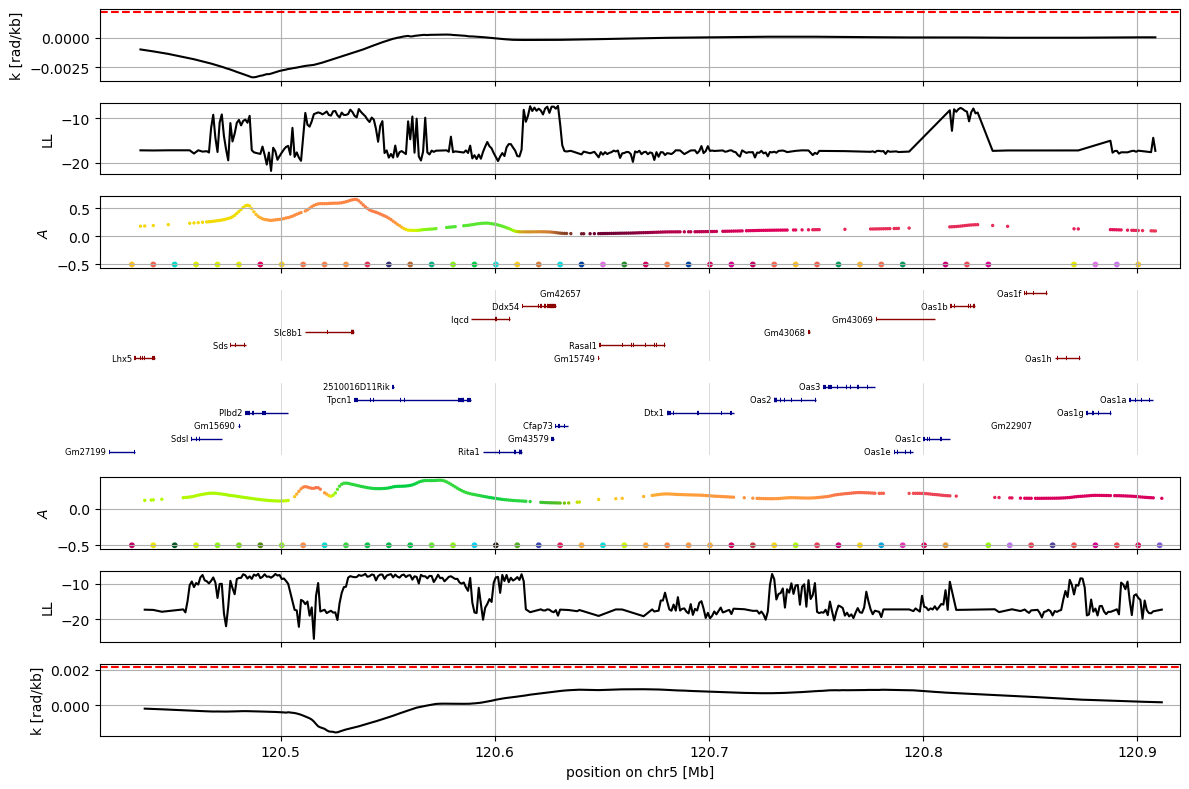

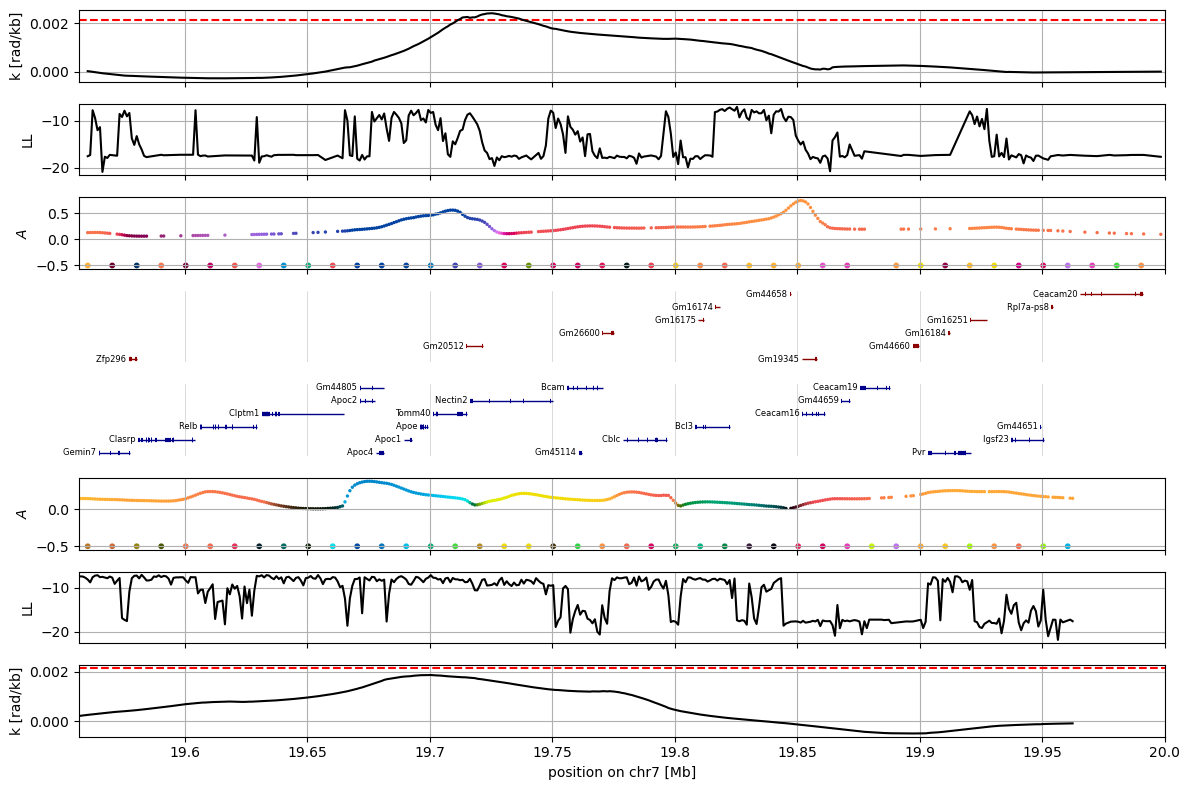

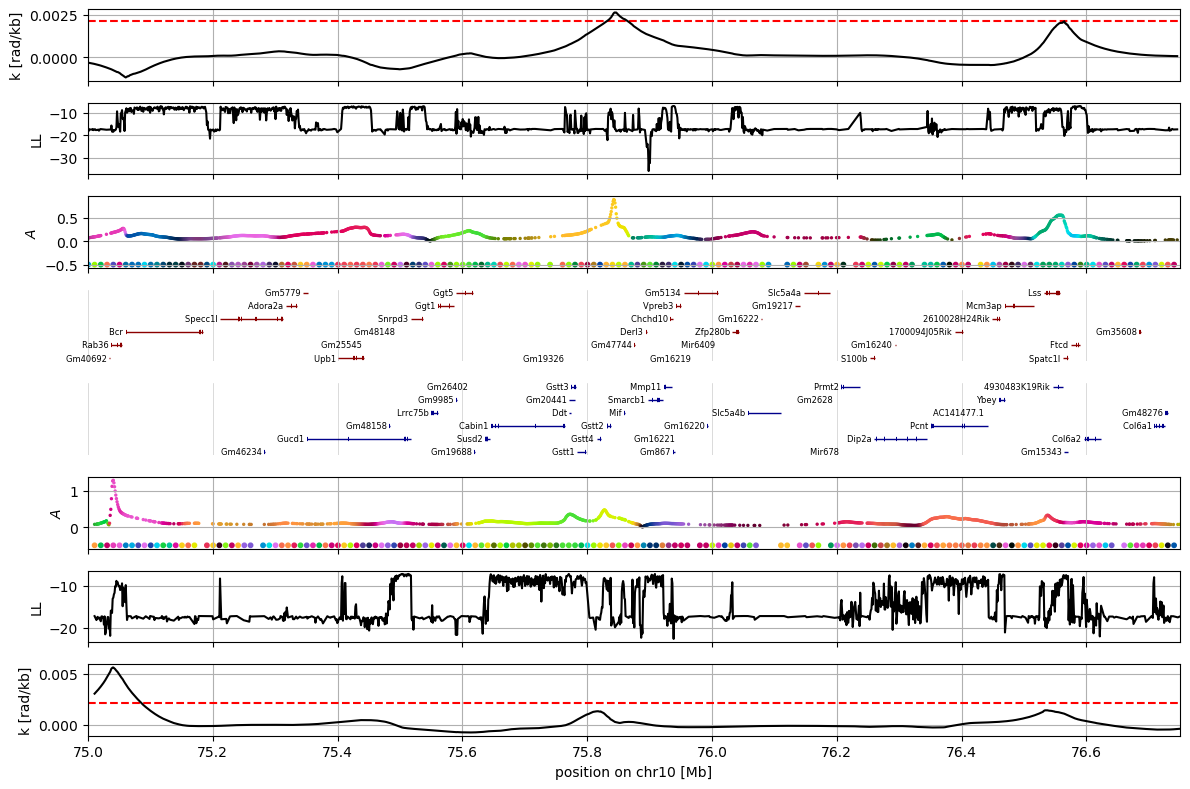

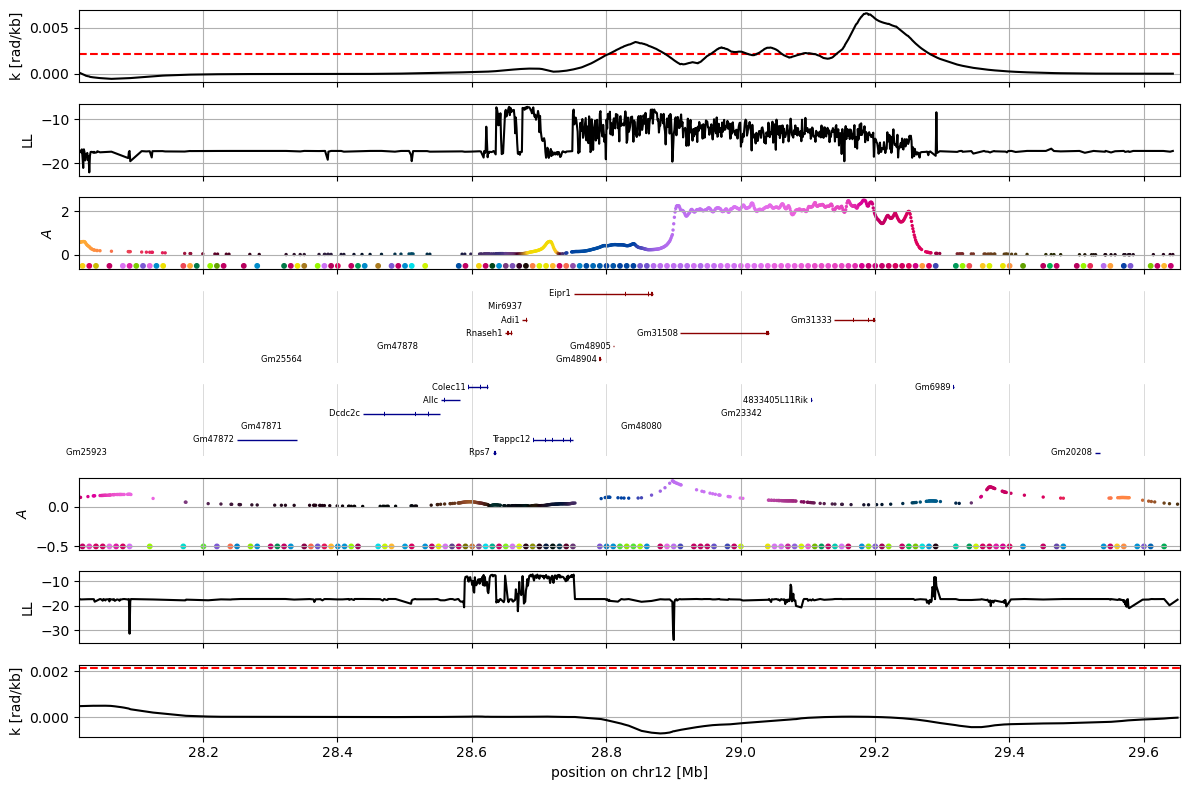

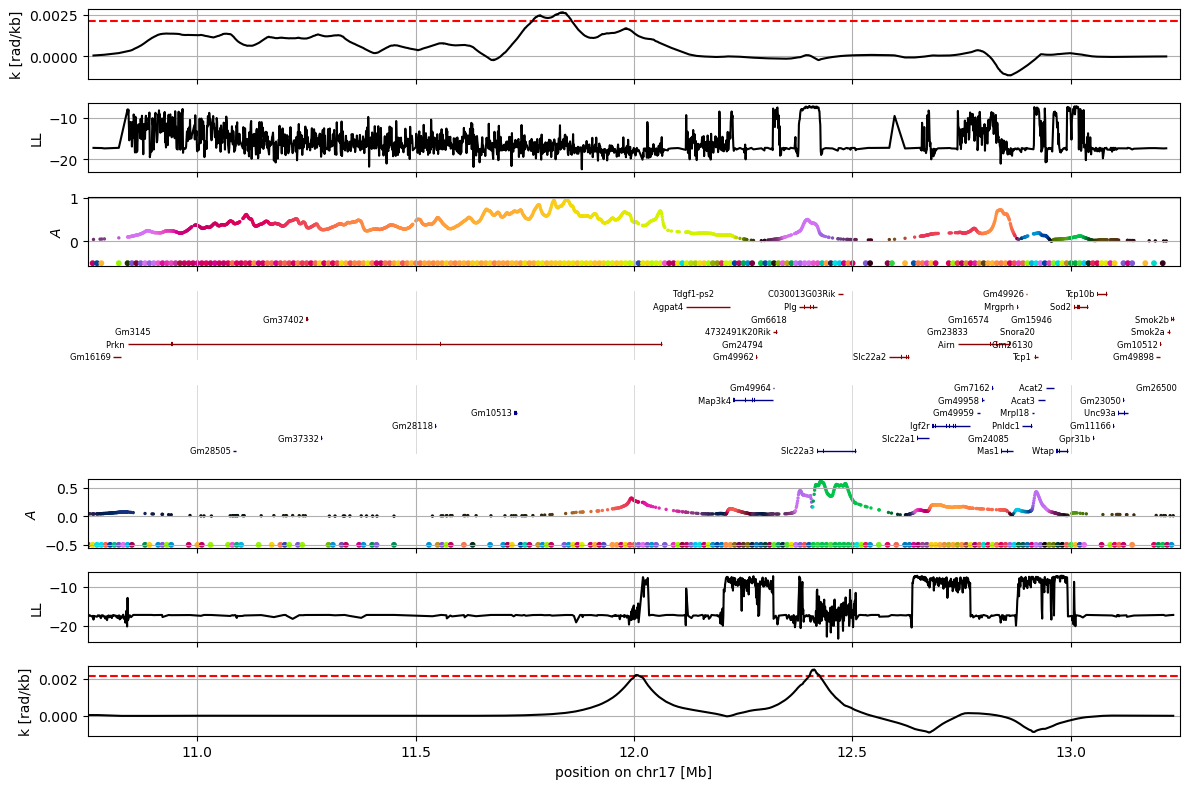

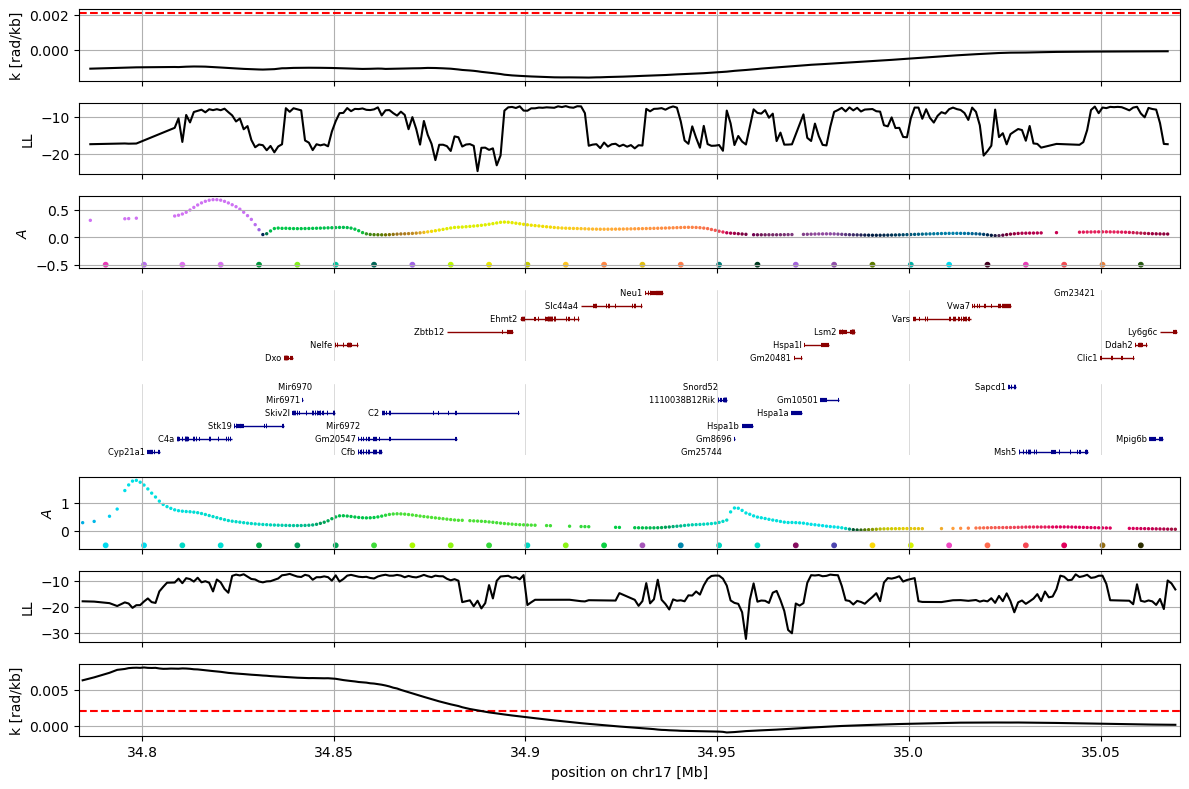

In [3]:
# removed regions :
# 'chr5:104_888_056:107_620_085',
# 'chr5:121_017_471:126_000_000',

Regions = ['chr2:11_800_000:13_600_000',
           'chr5:120_415_452:120_920_000',
           'chr7:19_557_000:20_000_000',
           'chr10:75_000_000:76_750_000',
           'chr12:28015438:29654150',
           'chr17:10_750_000:13_250_000',
           'chr17:34_783_585:35_070_714']

# k mean
ω = 2*np.pi/24 #  [rad/h] 
v_mean = 34 # [bp/s]
v_mean *= 1e-3 # [kb/s]
v_mean *= 3600 # [kb/h]
k_mean = ω/v_mean # [rad/kb]

for region in Regions:
    chrom, start, end = region.split(':')
    start = int(start)
    end = int(end)
    
    # plot : 2 strands * (k, phase, LL, genes)
    N_tracks = 4
    fig, axes = plt.subplots(nrows=2*N_tracks, ncols=1, figsize=(12, 8))
    fplus = N_tracks-1
    fminus = N_tracks
    for strand in ['+','-']:

        region_data = extended[(extended['chr'] == chrom) & (extended['start'] >= start) & (extended['end'] <= end) & (extended['strand'] == strand)]

        region_gtf = gene_gtf[(gene_gtf['chrom'] == chrom) & (gene_gtf['start'] >= start) & (gene_gtf['end'] <= end) & (gene_gtf['strand'] == strand)]

        x = region_data['start'].values+bin_size/2

        # elongation rate
        k = region_data['k'].values

        # phase
        phi = region_data['phi'].values
        A = region_data['amp'].values
        σ_A = region_data['var_amp'].values
        col = p2lc(phi,amp=A,th_amp=0.1)

        # k effective dphi/dx
        k_eff = (phi[1:] - phi[:-1])/(x[1:] - x[:-1]) # [rad/bp]
        k_eff *= 1e3 # [rad/kb]

        # bin phase
        x_bin = bin_phase_amp[strand][(bin_phase_amp[strand]['chr'] == chrom) & (bin_phase_amp[strand]['start'] >= start) & (bin_phase_amp[strand]['end'] <= end)]['start'].values + bin_size/2
        phi_bin = bin_phase_amp[strand][(bin_phase_amp[strand]['chr'] == chrom) & (bin_phase_amp[strand]['start'] >= start) & (bin_phase_amp[strand]['end'] <= end)]['phase'].values        
        amp_bin = bin_phase_amp[strand][(bin_phase_amp[strand]['chr'] == chrom) & (bin_phase_amp[strand]['start'] >= start) & (bin_phase_amp[strand]['end'] <= end)]['amplitude'].values
        col_bin = p2lc(phi_bin,amp=amp_bin,th_amp=0.2)

        # LL
        LL = region_data['LL'].values

        # get genes in region
        genes = region_gtf[(region_gtf['feature'] == 'gene')]['gene_id'].values

        # first track: genes
        if strand == '+':
            ax = axes[fplus]
            gene_color = 'darkred'
        elif strand == '-':
            ax = axes[fminus]
            gene_color = 'darkblue'
        
        y = 0
        for gene in genes:
            my_gene = region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'gene')]
            if len(my_gene) > 0:
                my_gene = my_gene.iloc[0]

            ax.hlines(y,my_gene.start,my_gene.end, color=gene_color, linewidth=1)
            ax.text(my_gene.start, y, my_gene.gene_name+' ', fontsize=6,ha='right', va='center')

            for exon in region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'exon')].itertuples(index=False):
                ax.hlines(y,exon.start,exon.end, color=gene_color, linewidth=3)
            
            y = (y+1)%6
        ax.set_xlim([start,end])
        for tick in ax.get_xticks():
            ax.axvline(tick, color='k', alpha=0.2, linewidth=0.5)
        ax.set_ylabel('genes')
        ax.axis('off')

        # next track Amp and phase
        if strand == '+':
            fplus -=1
            ax = axes[fplus]
        elif strand == '-':
            fminus +=1
            ax = axes[fminus]
        
        ax.scatter(x, A, c=col, s=2)
        ax.scatter(x_bin, -.5*np.ones(len(x_bin)), c=col_bin, s=10)
        ax.set_xticklabels([])
        ax.set_xlim([start,end])
        ax.set_ylabel(r'$A$')
        ax.grid()

        # next track LL
        if strand == '+':
            fplus -=1
            ax = axes[fplus]
        elif strand == '-':
            fminus +=1
            ax = axes[fminus]

        ax.plot(x, LL, 'k')
        ax.set_xticklabels([])
        ax.set_xlim([start,end])
        ax.set_ylabel('LL')
        ax.grid()

        # next track k
        if strand == '+':
            fplus -=1
            ax = axes[fplus]
        elif strand == '-':
            fminus +=1
            ax = axes[fminus]

        ax.hlines(k_mean, start, end, color='r', linestyle='--')
        ax.plot(x, k, 'k')
        #ax.plot(x[:-1]+(bin_size*1e-3)/2, k_eff)
        #ax.set_ylim([-5*k_mean,5*k_mean])
        ax.set_xticklabels([])
        ax.set_xlim([start,end])
        ax.set_ylabel('k [rad/kb]')
        ax.grid()
    
    ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
    ax.set_xlabel(f'position on {chrom} [Mb]')

    fig.tight_layout()
    fig.savefig(f"fig/extended_kalman/bin{bin_size}bp/{region.replace(':','_')}.pdf")


In [16]:
region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'exon')]

,chrom,source,feature,start,end,score,strand,frame,attributes,gene_id,gene_type,gene_name,transcript_id,transcript_type,transcript_name
1641132,chr17,HAVANA,exon,35066110,35066184,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000097337.7,protein_coding,Mpig6b-201
1641135,chr17,HAVANA,exon,35065563,35065904,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000097337.7,protein_coding,Mpig6b-201
1641137,chr17,HAVANA,exon,35065319,35065409,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000097337.7,protein_coding,Mpig6b-201
1641139,chr17,HAVANA,exon,35062693,35064436,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000097337.7,protein_coding,Mpig6b-201
1641145,chr17,HAVANA,exon,35066110,35066170,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000174190.1,protein_coding,Mpig6b-202
1641148,chr17,HAVANA,exon,35065563,35065904,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000174190.1,protein_coding,Mpig6b-202
1641150,chr17,HAVANA,exon,35065319,35065409,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000174190.1,protein_coding,Mpig6b-202
1641152,chr17,HAVANA,exon,35064904,35064956,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000174190.1,protein_coding,Mpig6b-202
1641154,chr17,HAVANA,exon,35064686,35064762,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000174190.1,protein_coding,Mpig6b-202
1641156,chr17,HAVANA,exon,35064332,35064436,.,-,.,"gene_id ""ENSMUSG00000073414.8""; transcript_id ...",ENSMUSG00000073414.8,protein_coding,Mpig6b,ENSMUST00000174190.1,protein_coding,Mpig6b-202


In [10]:
my_gene.end

11910310

In [4]:
region_data

,chr,start,end,strand,LL,a,var_a,b,var_b,cov_ab,k,var_k,lambda,var_lambda,amp,var_amp,phi,var_phi
1546468,chr17,34784000,34785000,-,-17.820430,-0.181974,0.030265,-0.242339,0.015459,0.014491,0.006380,0.000010,-0.039281,0.007792,0.303056,0.074707,4.068307,0.119882
1546469,chr17,34787000,34788000,-,-17.940088,-0.224154,0.032838,-0.266340,0.015842,0.015478,0.006789,0.000009,-0.062396,0.006801,0.348112,0.079636,4.012786,0.086976
1546470,chr17,34791000,34792000,-,-18.540893,-0.386981,0.040845,-0.362327,0.017478,0.018998,0.007424,0.000008,-0.129621,0.005076,0.530127,0.096320,3.894101,0.033576
1546471,chr17,34793000,34794000,-,-19.658368,-0.612109,0.039196,-0.491024,0.016170,0.017677,0.007830,0.000008,-0.182951,0.003700,0.784718,0.090719,3.817664,0.012877
1546472,chr17,34795000,34796000,-,-18.244547,-1.211239,0.044827,-0.779503,0.016222,0.019676,0.007956,0.000008,-0.135601,0.004808,1.440390,0.100400,3.713426,0.003225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1546711,chr17,35065000,35066000,-,-16.920019,0.078407,0.003277,0.022693,0.003161,-0.000025,0.000217,0.000013,-0.016494,0.009050,0.081625,0.006388,0.281722,0.477835
1546712,chr17,35066000,35067000,-,-20.830781,0.075489,0.003271,0.022719,0.003166,-0.000027,0.000213,0.000013,-0.019482,0.009048,0.078834,0.006382,0.292336,0.513206
1546713,chr17,35067000,35068000,-,-9.727417,0.072005,0.003265,0.022395,0.003167,-0.000030,0.000205,0.000013,-0.018729,0.009045,0.075408,0.006373,0.301529,0.561347
1546714,chr17,35068000,35069000,-,-10.891693,0.068805,0.003272,0.022494,0.003175,-0.000033,0.000202,0.000013,-0.015799,0.009056,0.072388,0.006380,0.315979,0.611488
